# Sheet 06 - Generative Adversarial Networks

Introduction to Deep Learning - Summer Semester 2026

Ulf Krumnack & Robin Rawiel - Universität OsnabrückDue: May 31, 2026

In this exercise sheet you will focus on the core GAN material up to the
training challenges and the motivation for Wasserstein GANs. The goal is
to connect the adversarial idea from the lecture and script to a compact
MNIST implementation. You will derive the basic GAN objective, implement
a small generator and discriminator, and compare two generator losses to
see why GAN training can become unstable.

## Task 1: Theory and GAN Intuition \[6 points\]

### 1.1 Why Adversarial Learning? \[2 points\]

1.  Why can pixel-wise reconstruction losses in models such as
    autoencoders or VAEs lead to blurry outputs when the model is
    uncertain about fine detail?

2.  Explain how a GAN replaces this fixed reconstruction objective with
    an adversarial one. What are the roles of the **generator** $G$ and
    the **discriminator** $D$?

**Answers:**

1. When the model is unsure about fine details, it hedges its bets and outputs the average of all plausible images. MSE rewards that safe middle ground, so the result is blurry.

2. Instead of a fixed loss, a GAN uses a learned critic. The generator $G$ turns random noise into fake images and tries to fool the discriminator. The discriminator $D$ tries to tell real from fake. Because $G$ has to keep up with an improving $D$, it is forced to produce sharp, realistic images rather than blurry averages.

---

### 1.2 Minimax Game and Nash Equilibrium \[2 points\]

1.  Write down the GAN minimax objective
    $$\min_G \max_D V(D, G) = \ldots$$
    and explain the meaning of the two expectation terms.

2.  What is a **Nash equilibrium** in this setting? If the generator
    distribution matches the real data distribution, what does the
    optimal discriminator output?

**Answers:**

1. $$\min_G \max_D V(D,G) = \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p(z)}[\log(1 - D(G(z)))]$$

   The first term rewards $D$ for correctly labelling real data as real. The second term rewards $D$ for spotting fakes, while $G$ tries to push it in the opposite direction.

2. A Nash equilibrium is where neither player gains by changing only their own strategy. If $p_G = p_{\text{data}}$, the discriminator can't distinguish real from fake, so the optimal output is $D^*(x) = \tfrac{1}{2}$ everywhere.

---

### 1.3 Fragility of Competition \[2 points\]

1.  Why can the original minimax generator loss lead to very weak
    gradients early in training?

2.  What is **mode collapse**?

3.  Why does the non-saturating generator loss
    $$\mathcal{L}_G = -\mathbb{E}_{z \sim p(z)}[\log D(G(z))]$$
    often work better in practice?

**Answers:**

1. Early on, $D$ easily rejects $G$'s outputs, so $D(G(z)) \approx 0$ and $\log(1 - D(G(z))) \approx 0$. The loss is stuck near zero and $G$ gets almost no gradient to learn from.

2. The generator finds a few outputs that fool $D$ and keeps producing only those, completely ignoring the rest of the data distribution.

3. When $D(G(z)) \approx 0$, the term $-\log D(G(z))$ shoots to $+\infty$ instead of flattening out, giving $G$ a strong gradient even when $D$ is winning.

---

## Common Setup

We reuse the lightweight MNIST setup from the previous generative-model
sheet and keep the runtime manageable by working on subsets rather than
the full dataset.

In this part you should:

- load the MNIST subsets and create the data loaders,
- map real images from $[0, 1]$ to $[-1, 1]$ for the discriminator, and
- add one helper for flattening images and one for displaying image
  grids.

In [49]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("mps" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
full_test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_subset = Subset(full_train_dataset, range(8000))
test_subset = Subset(full_test_dataset, range(1000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=256, shuffle=False)


def scale_to_tanh(images):
    """Map images from [0, 1] to [-1, 1] for the discriminator."""
    return 2 * images - 1


def flatten_images(images):
    """Flatten a batch of images to vectors."""
    return images.flatten(start_dim=1)


def show_grid(images, title, nrow=8, normalize=False, value_range=None):
    """Display image batches as a grid."""
    grid = torchvision.utils.make_grid(images, nrow=nrow, normalize=normalize, value_range=value_range)
    plt.figure(figsize=(10, 10))
    plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.27MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 242kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.88MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.84MB/s]


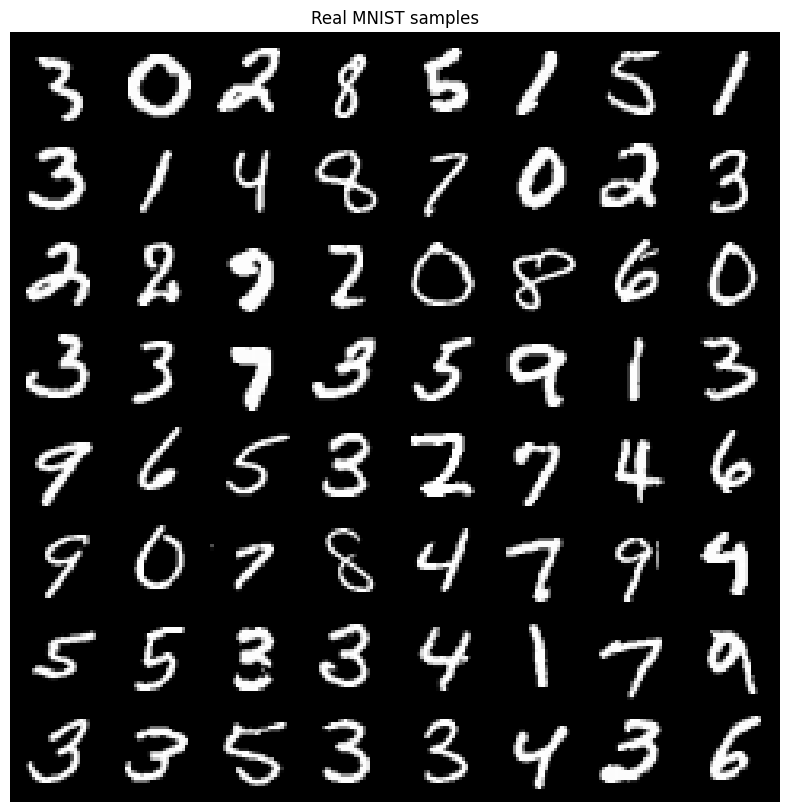

In [50]:
real_batch, _ = next(iter(train_loader))
show_grid(real_batch[:64], title="Real MNIST samples", nrow=8)

## Task 2: GAN on MNIST \[10 points\]

**Learning objectives:**

- implement a simple generator and discriminator,
- train them with alternating optimization, and
- inspect how generated samples and losses evolve over time.

Tip: get the loss functions and the update order correct first. If the
model keeps generating pure noise, check whether you detached the fake
samples during the discriminator update and whether the real images were
scaled to $[-1, 1]$.

### 2.1 Build Generator and Discriminator \[2 points\]

Use a latent dimension of 64 and represent each MNIST image as a vector
of length $28 \cdot 28 = 784$.

- The **generator** should map a noise vector $z \in \mathbb{R}^{64}$ to
  an image vector in $[-1, 1]$ using a `tanh` output layer.
- The **discriminator** should map an image vector to a scalar
  probability in $[0, 1]$ using a `sigmoid` output layer.

In [51]:
latent_dim = 64
image_dim = 28 * 28


class Generator(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(in_features=latent_dim, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=512),
            nn.ReLU(),
            nn.Linear(in_features=512, out_features=image_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.decoder(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.discriminator = nn.Sequential(
            nn.Linear(in_features=784, out_features=512),
            nn.ReLU(),
            nn.Linear(in_features=512, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=1),
            nn.Sigmoid()
        )


    def forward(self, x):
        return self.discriminator(x)

In [52]:
def make_gan(latent_dim=64):
    generator = Generator(latent_dim).to(device)
    discriminator = Discriminator().to(device)
    return generator, discriminator


generator, discriminator = make_gan(latent_dim)

### 2.2 Losses and Update Steps \[2 points\]

In this task you will implement:

- the discriminator loss for real and fake samples,
- the non-saturating generator loss used in the main training run, and
- one alternating training step that updates $D$ first and $G$ second.

Keep the optional `mode="minimax"` branch in `generator_loss`, because
you will reuse it in Task 3.

In [53]:
bce = nn.BCELoss()


def discriminator_loss(d_real, d_fake):
    return bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))


def generator_loss(d_fake, mode="non_saturating"):
    if mode == "non_saturating":
        return bce(d_fake, torch.ones_like(d_fake))
    else:  # minimax
        return -bce(d_fake, torch.zeros_like(d_fake))


def gan_train_step(
    generator,
    discriminator,
    optimizer_G,
    optimizer_D,
    real_images,
    generator_mode="non_saturating",
):
    batch_size = real_images.size(0)
    real_images = scale_to_tanh(real_images.to(device))
    real_vectors = flatten_images(real_images)

    fake_images = generator(torch.randn(batch_size, latent_dim, device=device))
    fake_vectors = flatten_images(fake_images.detach())

    d_fake = discriminator(fake_vectors)
    d_real = discriminator(real_vectors)

    d_loss = discriminator_loss(d_real, d_fake)
    optimizer_D.zero_grad()
    d_loss.backward()
    optimizer_D.step()

    fake_vectors = flatten_images(fake_images)
    d_fake = discriminator(fake_vectors)

    g_loss = generator_loss(d_fake, mode=generator_mode)
    optimizer_G.zero_grad()
    g_loss.backward()
    optimizer_G.step()

    return d_loss.item(), g_loss.item()


### 2.3 Train and Inspect the GAN \[4 points\]

Train the GAN with the **non-saturating** generator loss for a short
run.

Your result in this task should include all of the following:

- a plot of discriminator and generator losses over epochs,
- sample snapshots from a fixed noise batch at several epochs, and
- one larger grid of final generated samples.

In [54]:
fixed_noise = torch.randn(64, latent_dim, device=device)


def train_gan(
    generator,
    discriminator,
    loader,
    epochs=10,
    lr=2e-4,
    generator_mode="non_saturating",
):
    optimizer_G = optim.Adam(generator.parameters(), lr=lr)
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

    d_losses, g_losses = [], []
    snapshot_epochs = {1, epochs // 2, epochs}

    for epoch in range(1, epochs + 1):
        d_epoch, g_epoch = 0.0, 0.0
        for images, _ in loader:
            d_loss, g_loss = gan_train_step(
                generator, discriminator, optimizer_G, optimizer_D, images, generator_mode
            )
            d_epoch += d_loss
            g_epoch += g_loss

        d_losses.append(d_epoch / len(loader))
        g_losses.append(g_epoch / len(loader))

        if epoch in snapshot_epochs:
            with torch.no_grad():
                samples = generator(fixed_noise).view(-1, 1, 28, 28)
            show_grid(samples, title=f"Epoch {epoch}", nrow=8, normalize=True, value_range=(-1, 1))

    plt.figure(figsize=(8, 4))
    plt.plot(d_losses, label="Discriminator")
    plt.plot(g_losses, label="Generator")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("GAN Training Losses")
    plt.show()

    return d_losses, g_losses


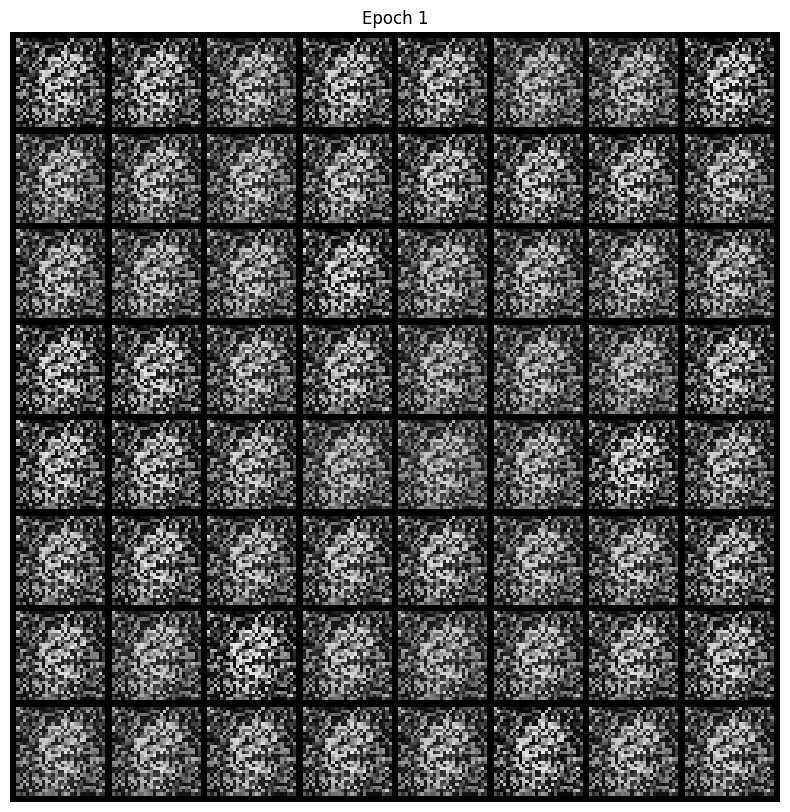

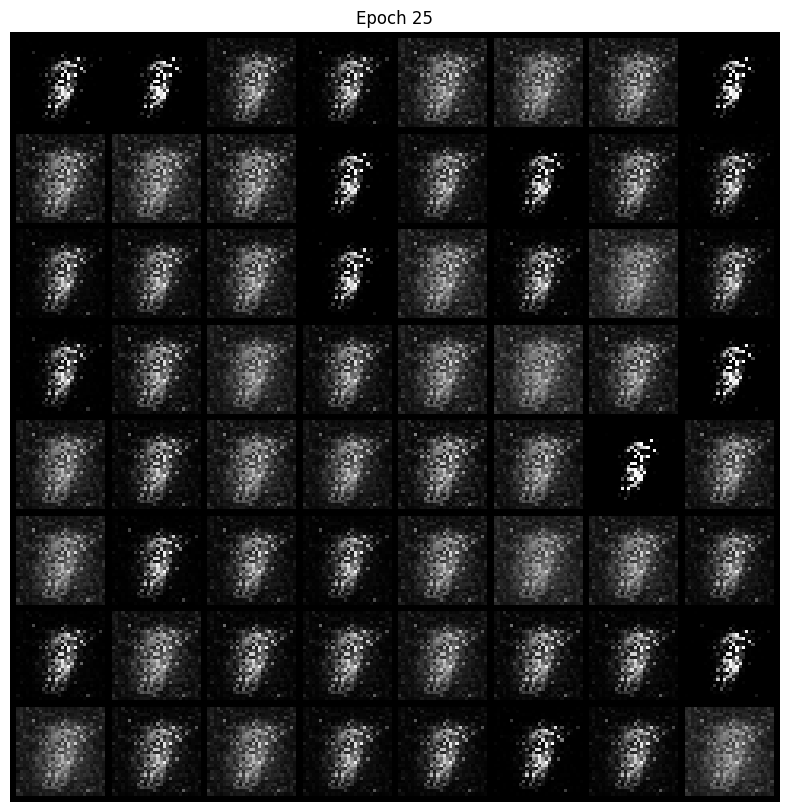

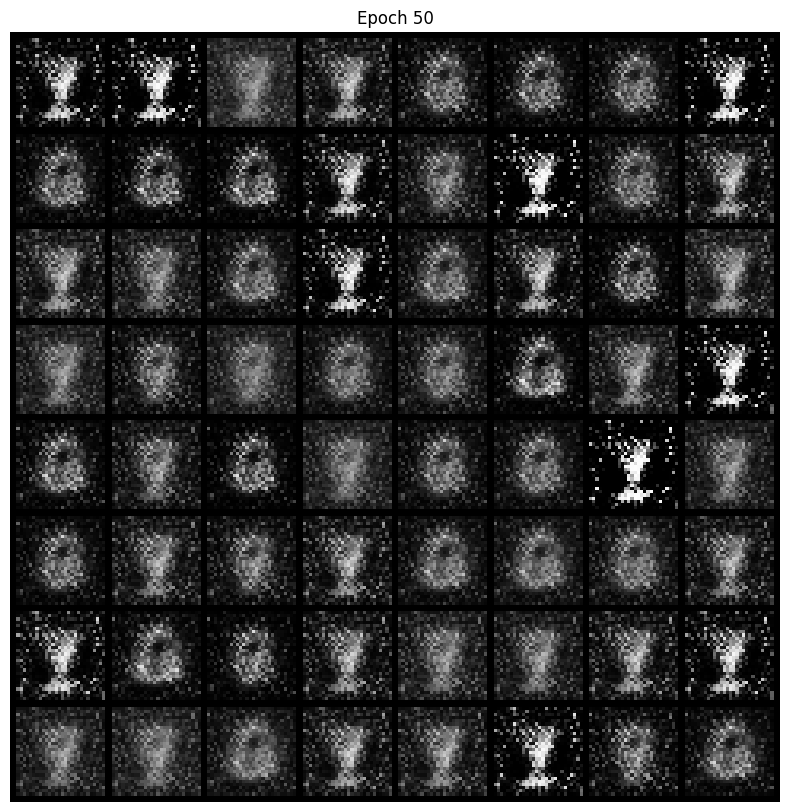

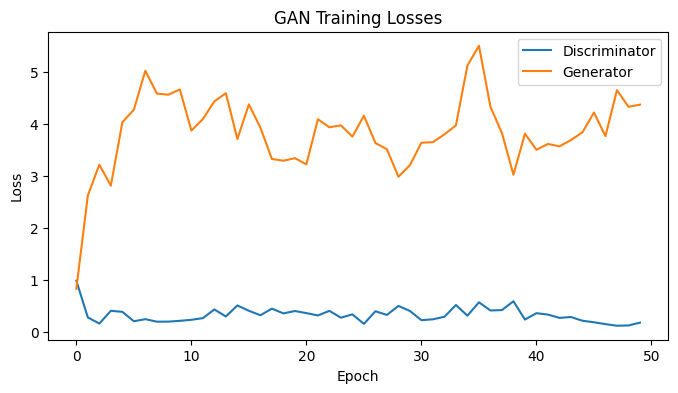

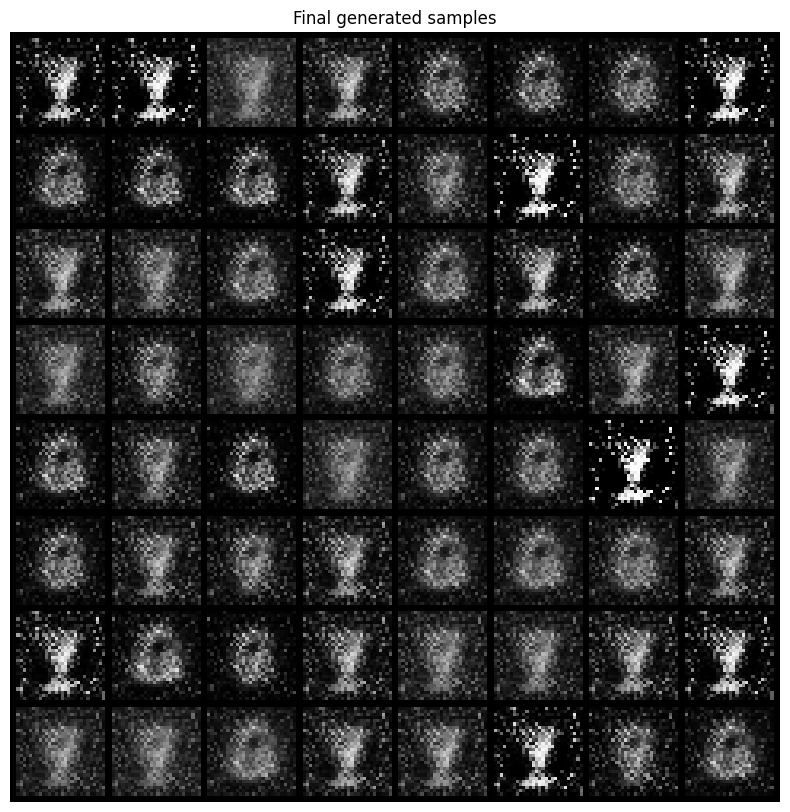

In [55]:
generator, discriminator = make_gan(latent_dim)
d_losses, g_losses = train_gan(generator, discriminator, train_loader, epochs=50)

with torch.no_grad():
    final_samples = generator(fixed_noise).view(-1, 1, 28, 28)
show_grid(final_samples, title="Final generated samples", nrow=8, normalize=True, value_range=(-1, 1))


### 2.4 Interpret the GAN Results \[2 points\]

After inspecting the losses and sample grids, answer the following
questions:

1.  What would reasonably balanced GAN training look like in the loss
    curves and sample grids? Why should you not expect perfectly flat
    losses?

2.  What visual or quantitative sign would make you suspect either mode
    collapse or an overpowered discriminator?

**Answers:**

1. Balanced training shows both losses staying in a similar range without one consistently dominating — discriminator loss around 1.0–1.4 and generator loss gradually decreasing as images improve. Perfect flatness is not expected because G and D keep updating in response to each other, so losses naturally oscillate as the competition shifts back and forth. The sample grids should show increasingly recognizable digit shapes over epochs.

2. Mode collapse: the generated grid shows the same digit (or a few digits) repeated across all 64 samples, no matter the noise input. Overpowered discriminator: the generator loss shoots very high and the samples remain pure noise throughout training — D has learned to reject everything before G gets a chance to improve.

## Task 3: A Short Fragility Experiment \[4 points\]

**Learning objectives:**

- compare the original minimax generator loss to the non-saturating
  variant, and
- connect the observed training behavior to the lecture discussion of
  vanishing gradients and instability.

In this task, reuse the same architecture and training function from
Task 2, but switch the generator objective through the `generator_mode`
argument.

Important: the raw generator loss values for the two objectives are not
directly comparable, because the loss formulas are different. Focus on
whether the samples improve, whether training appears to get stuck, and
how strongly the discriminator dominates early in training.

### 3.1 Compare Two Generator Losses \[2 points\]

Train one GAN with the original **minimax** generator loss and one GAN
with the **non-saturating** generator loss for a short run.

Plot the losses for each run and show one final sample grid from each
model.

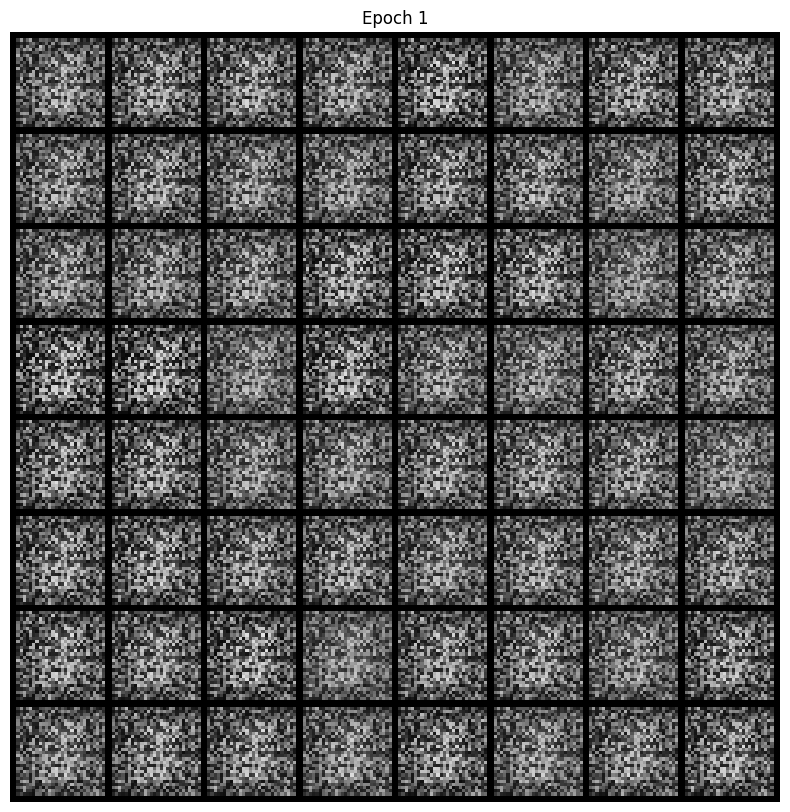

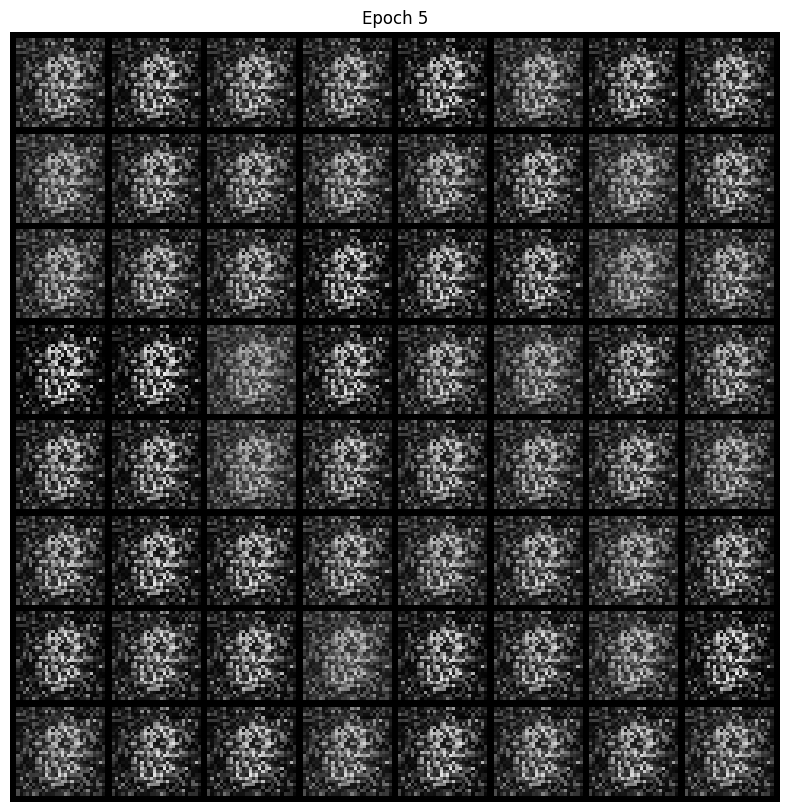

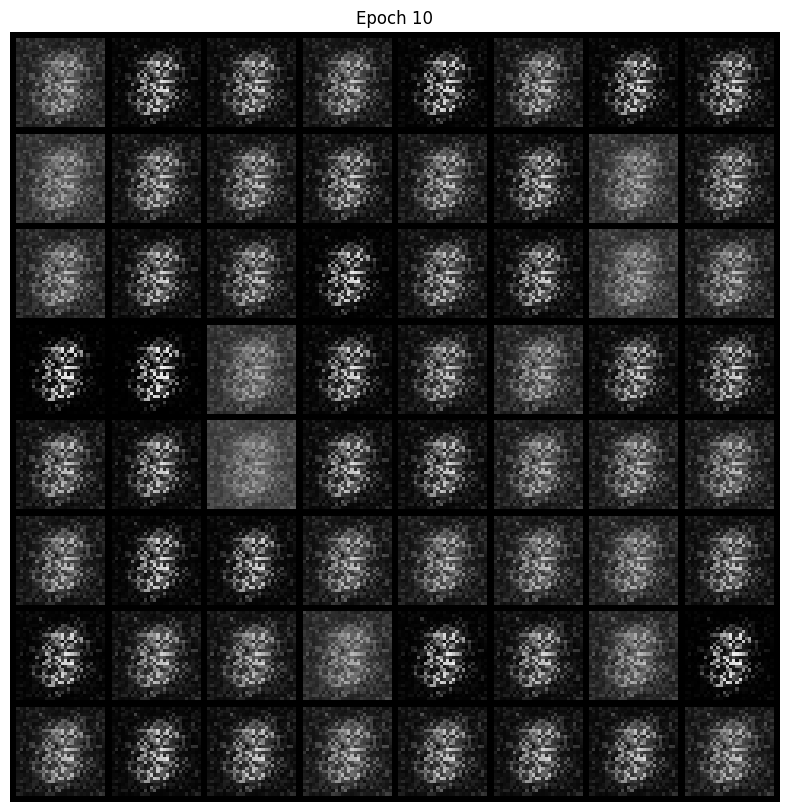

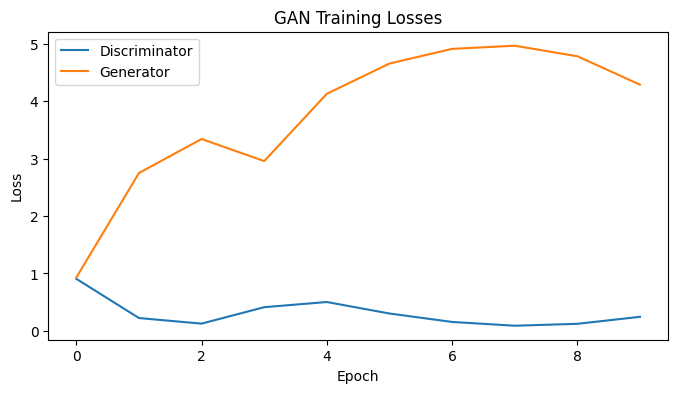

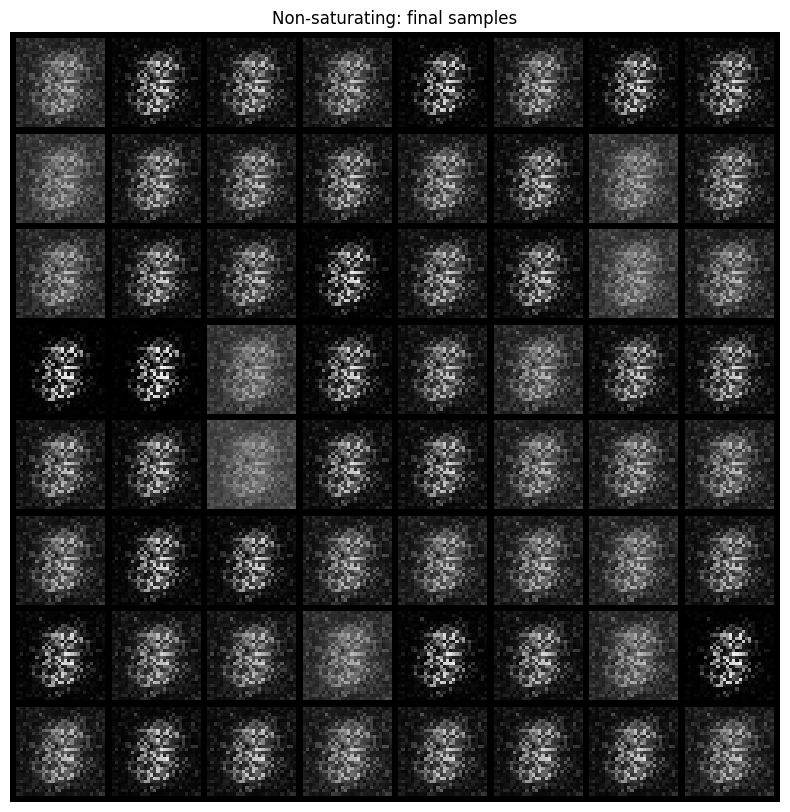

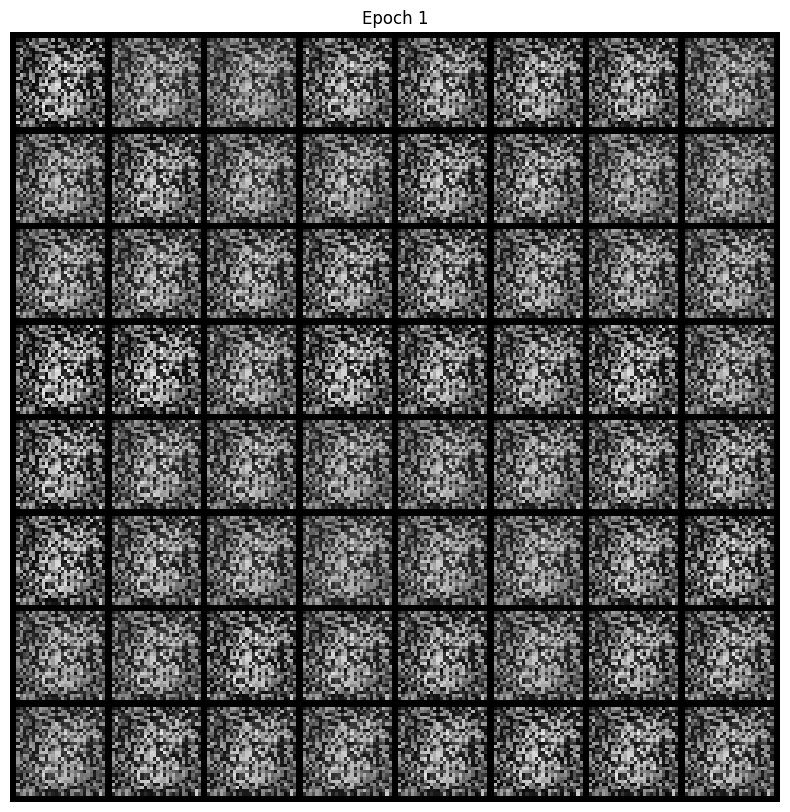

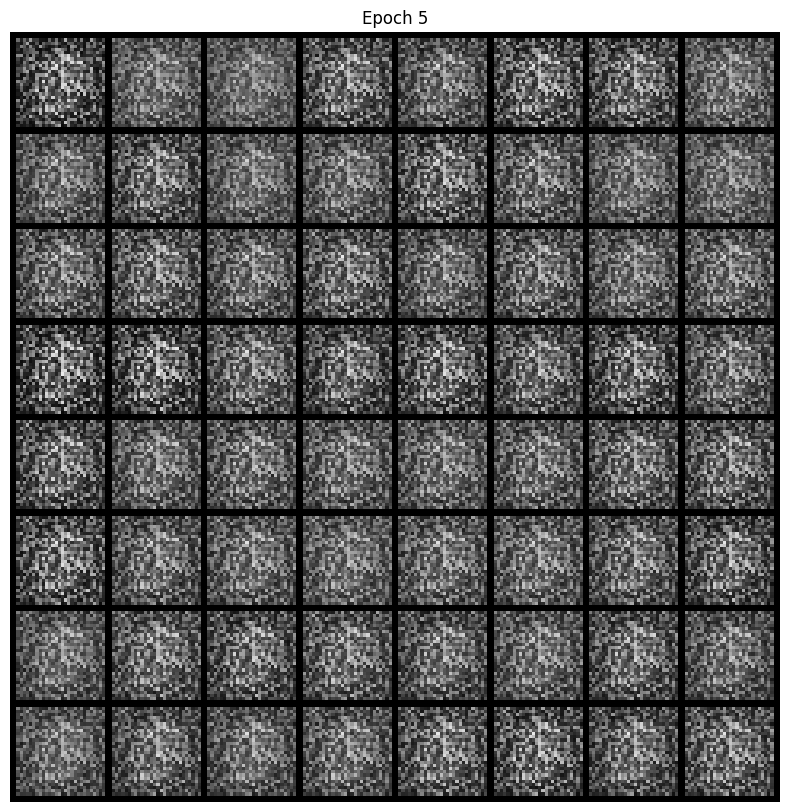

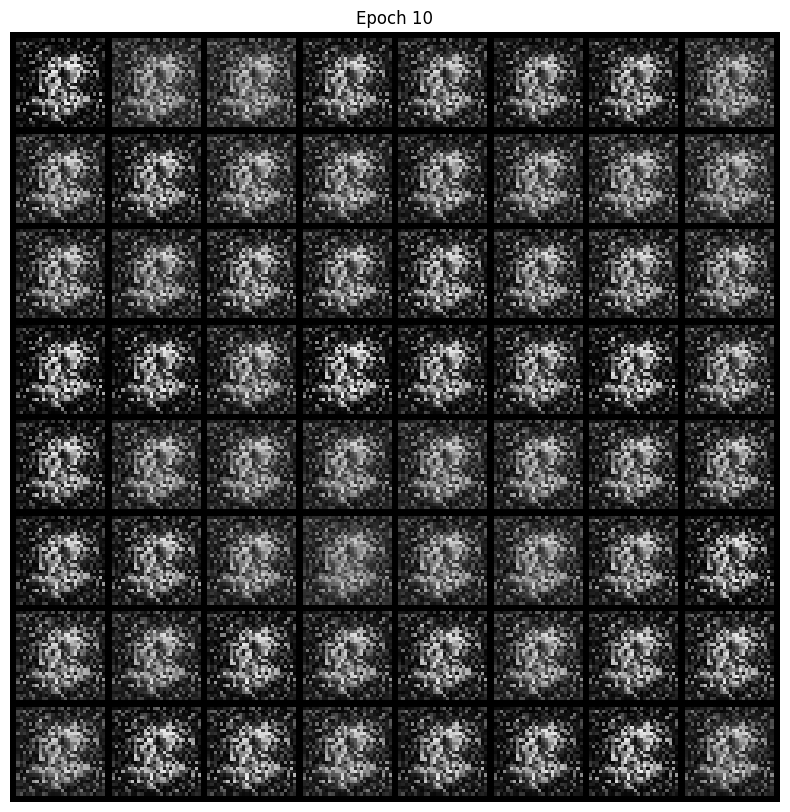

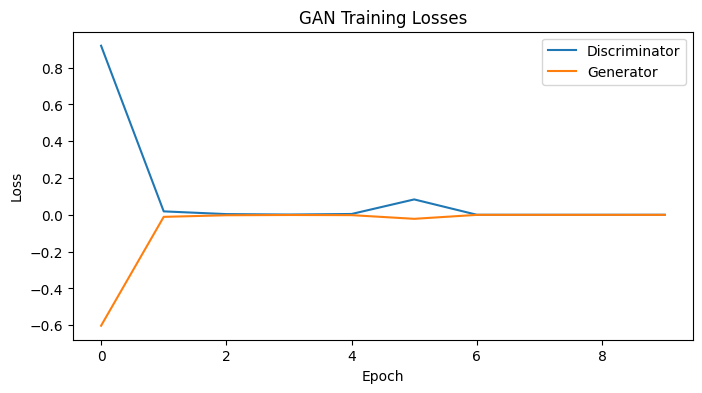

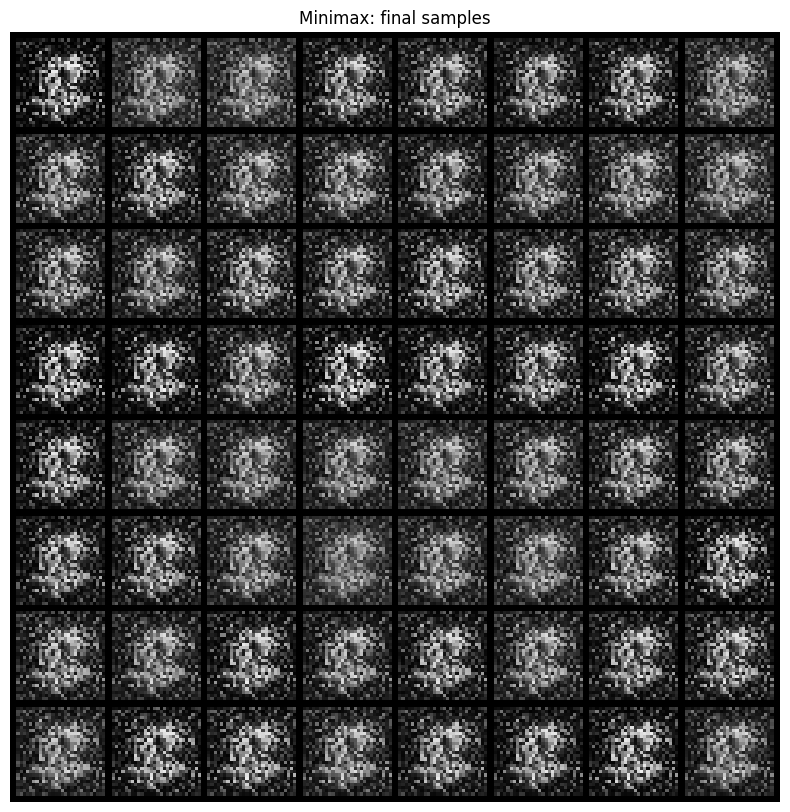

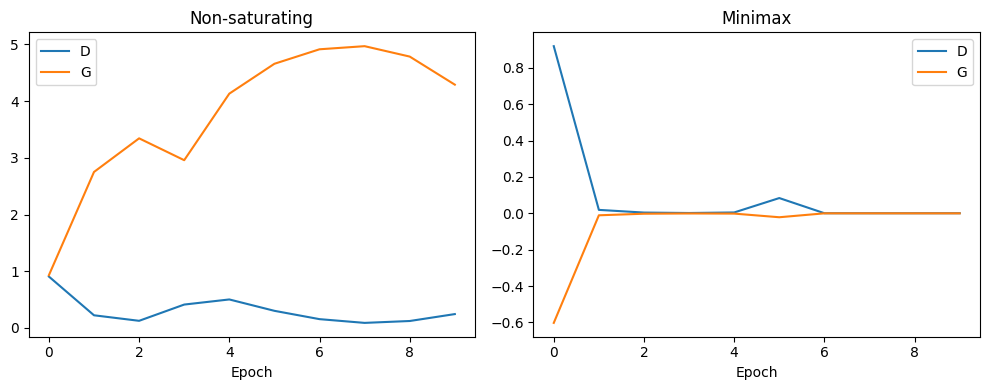

In [56]:
gen_ns, disc_ns = make_gan(latent_dim)
d_losses_ns, g_losses_ns = train_gan(gen_ns, disc_ns, train_loader, epochs=10, generator_mode="non_saturating")

with torch.no_grad():
    samples_ns = gen_ns(fixed_noise).view(-1, 1, 28, 28)
show_grid(samples_ns, title="Non-saturating: final samples", nrow=8, normalize=True, value_range=(-1, 1))

gen_mm, disc_mm = make_gan(latent_dim)
d_losses_mm, g_losses_mm = train_gan(gen_mm, disc_mm, train_loader, epochs=10, generator_mode="minimax")

with torch.no_grad():
    samples_mm = gen_mm(fixed_noise).view(-1, 1, 28, 28)
show_grid(samples_mm, title="Minimax: final samples", nrow=8, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(d_losses_ns, label="D"); plt.plot(g_losses_ns, label="G")
plt.title("Non-saturating"); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(d_losses_mm, label="D"); plt.plot(g_losses_mm, label="G")
plt.title("Minimax"); plt.xlabel("Epoch"); plt.legend()

plt.tight_layout()
plt.show()


### 3.2 Reflect on Training Fragility \[2 points\]

1.  Which generator objective gave the generator a better learning
    signal in your short run? Describe what you observed in the samples
    and the loss curves.

2.  How does this experiment illustrate the lecture claim that GAN
    training is a **fragile competition** rather than ordinary
    optimization?